In [9]:
# 감지된 이미지 관련 음성으로 들려 주기
# TTS(Text To Speech), STT(Speech To Text)

# 유기동물 탐지 후 보호소 안내 메세지 음성으로 출력
!pip install ultralytics
!pip install gTTS playsound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.4 MB/s eta 0:00:00


In [7]:
# TTS 연습
from gtts import gTTS
from IPython.display import Audio     # jupyrer notebook 용
from playsound import playsound       # local 편집기용(vsc ...)

def speakFunc(message):
    tts = gTTS(text=message, lang = 'ko')
    tts.save('yolotest.mp3')      # 음성 파일로 저장
    return Audio('yolotest.mp3', autoplay=True) # 재생(Jupyter)
    playsound('yolotest.mp3')   # 재생 (vcs...)
message = "메타가 글로벌 아이웨어 기업 에실로룩소티카와 손잡고 인공지능(AI) 기능을 탑재한 스마트 안경 2종을 국내 시장에 선보인다.19일 메타에 따르면 AI 글래스 제품인 '레이밴 메타'와 '오클리 메타'가 오는 25일 국내에 공식 출시된다."
speakFunc(message)

In [14]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio
from playsound import playsound
from datetime import datetime

# 보호소 정보 안내(텍스트 + 음성 재생)
def show_shelter_info_func(region, shelters, detected_info):
  shelter_info = shelters.get(region, shelters['기본'])
  pet_summary = f"{detected_info['count']}마리 ({' , '.join(detected_info['labels'])})"

  message = (
      f"유기 동물 탐지 결과 :\n"
      f" - 탐지된 동물 수  : {detected_info['count']}\n"
      f" - 종류 : {pet_summary}\n\n"
      f"{region} 지역 보호소 정보 :\n{shelter_info}"
  )
  print("보호소 정보 : ", message)

  # 음성 안내
  try:
      tss = gTTS(text=f"{region} 지역에 유기된 {pet_summary}가 감지 되었습니다. 가까운 보호소는 {shelter_info}입니다.", lang='ko')
      tss.save('yolo5shelter.mp3')
      return Audio('yolo5shelter.mp3', autoplay=True)
      # playsound('yolo5shelter.mp3')
  except Exception as e:
    print(f"음성안내 실패 : {e}")

def handle_stray_pet_func(region, shelters, detected_info):
    print('유기 동물로 추정됨')
    show_shelter_info_func(region, shelters, detected_info)

region = '테헤란로 사거리 삼원빌딩 앞'
shelters = {
    "서울":"서울 반려동물 보호센터: 02-1234-5678",
    "기본":"전국 반려동물 보호센터: 1577-8888"

}
detected_info = {
    "count":3,
    "labels":["호랑이","사자","코끼리"]
}

show_shelter_info_func(region, shelters, detected_info)

보호소 정보 :  유기 동물 탐지 결과 :
 - 탐지된 동물 수  : 3
 - 종류 : 3마리 (호랑이 , 사자 , 코끼리)

테헤란로 사거리 삼원빌딩 앞 지역 보호소 정보 :
전국 발려동물 보호센터: 1577-8888



0: 384x640 1 cat, 1 dog, 218.8ms
Speed: 7.2ms preprocess, 218.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


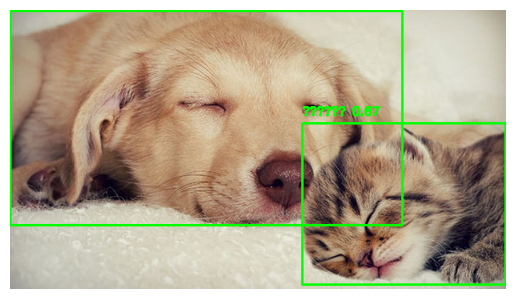

결과 이미지 저장 : yolo5out.jpg
감지된 동물 : dog
감지된 동물 : cat
유기 동물로 추정됨
보호소 정보 :  유기 동물 탐지 결과 :
 - 탐지된 동물 수  : 2
 - 종류 : 2마리 (냥이 , 댕댕이)

서울 지역 보호소 정보 :
서울 반려동물 보호센터: 02-1234-5678


In [20]:
# 본격적으로 이미지내 객체 감지 후 함수 호출

# 탐지 정보 로그 저장
def save_detection_log_func(image_path, detection_data):
  log_file = 'yolo5log.txt'
  now = datetime.now()
  timestamp = now.strftime('%Y-%m-%d %H:%M:%S')

  with open(log_file, 'a', encoding='utf8') as f:
    f.write(f'\n{timestamp} 이미지:{image_path}\n')
    f.write(f'탐지된 객체 수 :{len(detection_data)}\n')
    for d in detection_data:
      f.write(f" - {d['label']} : {d['box']} : {d['confidence']}\n")
      f.write('\n')


# 유기동물 감지 함수
def detect_pets_func(image_path):
  pet_desc = {
      'dog':'댕댕이',
      'cat':'냥이'
  }

  shelters = {
    "서울":"서울 반려동물 보호센터: 02-1234-5678",
    "부산":"부산 유기동물  보호소 : 051-1234-9876",
    "기본":"전국 반려동물 보호센터: 1577-8888"
  }

  stray_keywords = ['street', 'road', 'outside', 'stray']

  model = YOLO('yolo11n.pt')
  image = cv2.imread(image_path)

  if image is None:
    print('이미지를 부를 수 없어요')
    return

  results = model(image)
  detected_pets = []      # 감지된 객체 레이블 저장
  detection_data = []     # 감지된 객체 정보 저장

  for result in results:
    for box in result.boxes:
      x1, y1, x2, y2 = map(int, box.xyxy[0])
      label = result.names[int(box.cls[0])]
      confidence = box.conf[0].item()

      if label in pet_desc:
        detected_pets.append(label)
        detection_data.append({
            'label':pet_desc[label],
            'box':(x1, y1, x2, y2),
            'confidence':confidence
        })
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"{pet_desc[label]} {confidence:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

  # 결과 이미지 저장
  output_path = 'yolo5out.jpg'
  cv2.imwrite(output_path, image)

  plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

  print(f'결과 이미지 저장 : {output_path}')

  for pet in detected_pets:
    print(f'감지된 동물 : {pet}')

  # 감지 정보 파일로 저장
  save_detection_log_func(image_path, detection_data)

  # 유기동물 조건 확인
  # 감지 동물이 dog, cat이고 이미지 경로에 'street', 'stray' 등의 키워드가 포함되면 유기동물로 판단
  if (
      any(pet in ['dog', 'cat'] for pet in detected_pets) and
      any(keyword in image_path.lower() for keyword in stray_keywords)
  ):
    detected_info = {
          'count':len(detected_pets),
          'labels':sorted(set([d['label'] for d in detection_data]))
    }

    # 유기 동물로 판단 되었으므로 보호소 정보를 음성 + 텍스트로 안내
    handle_stray_pet_func("서울", shelters=shelters, detected_info=detected_info)
  else:
    print('유기동물이 감지되지 않아요')

detect_pets_func('street_ani.jpg')